<a href="https://www.kaggle.com/code/nadezhdaemelyanova/start-ml-final-project-eda?scriptVersionId=310931993" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sqlalchemy import create_engine
import re
from collections import Counter
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [2]:
# оформление графиков

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# кастомный список стоп-слов для частотного анализа текстов

custom_stop_words = {
    # предлоги
    'a', 'an', 'and', 'of', 'in', 'to', 'for', 'on', 'with', 'at', 'by', 'from', 'up', 'down', 'off', 'over', 'under', 'into', 'through', 
    'during', 'without', 'against', 'among', 'between', 'about', 'after', 'before', 'above', 'below', 'across', 'along', 'around', 'behind', 
    'beneath', 'beside', 'beyond', 'inside', 'near', 'outside', 'per', 'plus', 'since', 'than', 'via', 'within',
    # союзы и связки
    'and', 'or', 'but', 'so', 'for', 'nor', 'yet', 'because', 'if', 'then', 'else', 'when', 'where', 'which', 'while', 'whilst', 'whereas', 
    'whether', 'either', 'neither', 'both', 'not', 'only', 'just', 'as', 'like', 'than', 'that', 'these', 'those', 'this', 'those', 'such', 'same', 
    'different', 'other', 'another',
    # местоимения
    'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'her', 'its', 'our', 'their', 'mine', 'yours', 
    'hers', 'ours', 'theirs', 'myself', 'yourself', 'himself', 'herself', 'itself', 'ourselves', 'yourselves', 'themselves', 'who', 'whom', 'whose', 
    'which', 'what', 'whatever', 'whoever', 'whomever',
    # вспомогательные глаголы
    'be', 'am', 'are', 'is', 'was', 'were', 'being', 'been', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'get', 'gets', 'got', 
    'getting', 'go', 'goes', 'went', 'going', 'make', 'makes', 'made', 'making', 'see', 'sees', 'saw', 'seeing', 'say', 'says', 'said', 'saying', 
    'give', 'gives', 'gave', 'giving', 'find', 'finds', 'found', 'finding', 'think', 'thinks', 'thought', 'thinking',
    # частицы, артикли, местоимения-прилагательные
    'te', 'this', 'that', 'these', 'those', 'some', 'any', 'no', 'every', 'all', 'both', 'each', 'few', 'many', 'more', 'most', 'other', 'such', 
    'certain', 'several', 'various', 'neither', 'either', 'enough', 'plenty', 'little', 'less', 'much', 'lot', 'lots', 'a', 'an',
    # вопросительные слова
    'why', 'how', 'when', 'where', 'what', 'which', 'who', 'whom', 'whose',
    # прочие частотные
    'very', 'just', 'but', 'so', 'too', 'also', 'even', 'only', 'really', 'quite', 'rather', 'somewhat', 'almost', 'nearly', 'hardly', 'barely', 
    'scarcely', 'never', 'always', 'sometimes', 'often', 'usually', 'generally', 'specifically', 'particularly', 'especially', 'namely', 'indeed', 
    'surely', 'certainly', 'probably', 'perhaps', 'maybe', 'although', 'though', 'despite', 'nevertheless', 'nonetheless', 'otherwise', 'instead', 
    'meanwhile', 'furthermore', 'moreover', 'consequently', 'accordingly', 'hence', 'thus', 'therefore', 'then', 'now', 'here', 'there', 'wherever', 
    'everywhere', 'anywhere', 'nowhere', 'somewhere', 'anyway', 'anyhow', 'whatever', 'whenever', 'wherever', 'whichever', 'however', 'whomever'
}

In [ ]:
# # подключаемся к базе данных, импортируем таблицы и смотрим на них

# query = """
# WITH user_ranked AS (
#     SELECT 
#         *,
#         ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY timestamp DESC) as user_rn,
#         ROW_NUMBER() OVER (ORDER BY timestamp DESC) as global_rn
#     FROM public.feed_data
# )
# SELECT *
# FROM user_ranked
# WHERE user_rn = 1
#    OR global_rn <= 6000000 - 163205
# ORDER BY timestamp DESC
# LIMIT 6000000
# """

# engine = create_engine(
#     "postgresql://login:password@"
#     "postgres.lab.karpov.courses:6432/startml"
# )

# with engine.connect() as connection:
#     user_data = pd.read_sql('SELECT * FROM public.user_data', con=connection)
#     post_text_df = pd.read_sql('SELECT * FROM public.post_text_df', con=connection)
#     feed_data = pd.read_sql(query, con=connection)

In [ ]:
# df = (feed_data
#      .merge(user_data, on='user_id', how='left')
#      .merge(post_text_df, on='post_id', how='left')).drop(['user_rn', 'global_rn'], axis=1)

# df.head()

In [ ]:
# df.to_csv('all_data.csv', index=False)
# post_text_df.to_csv('post_text_df.csv', index=False)

In [ ]:
df = pd.read_csv('/kaggle/input/datasets/nadezhdaemelyanova/allcsv/all.csv', sep=';')
df.head()

# EDA
## общая информация о датасете
5890555 - именно такое количество строк появилось после SQL запроса: нужно было, чтобы все юзеры вошли в датасет в как можно большем количестве (чтобы было как можно больше информации для предсказаний по каждому юзеру)

In [5]:
# размер датасета
df.shape

(5890555, 14)

In [6]:
# информация о колонках: сразу видим, что нет пропусков
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5890555 entries, 0 to 5890554
Data columns (total 14 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  object
 1   user_id    int64 
 2   post_id    int64 
 3   action     object
 4   target     int64 
 5   gender     int64 
 6   age        int64 
 7   country    object
 8   city       object
 9   exp_group  int64 
 10  os         object
 11  source     object
 12  text       object
 13  topic      object
dtypes: int64(6), object(8)
memory usage: 674.1+ MB


In [7]:
# наличие или отсутствие дубликатов
df.duplicated().sum()

np.int64(0)

In [8]:
# описательные статистики числовых колонок (по сути смотрим только на возраст)
df.describe().round(3)

,user_id,post_id,target,gender,age,exp_group
count,5890555.000,5890555.000,5890555.000,5890555.000,5890555.000,5890555.000
mean,85105.227,3398.057,0.120,0.554,27.205,1.997
std,48970.979,2095.393,0.325,0.497,10.237,1.407
min,200.000,1.000,0.000,0.000,14.000,0.000
25%,41028.000,1528.000,0.000,0.000,19.000,1.000
50%,85508.000,3195.000,0.000,1.000,24.000,2.000
75%,127733.000,5207.000,0.000,1.000,33.000,3.000
max,168552.000,7319.000,1.000,1.000,95.000,4.000


In [9]:
# работа с timestamp

df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"исследуемый диапазон дат: с {df['timestamp'].min()} по {df['timestamp'].max()}")

исследуемый диапазон дат: с 2021-10-27 16:42:51 по 2021-12-29 23:51:06


In [10]:
# получаем признаки из timestamp: час, день недели, месяц
# секунды и минуты брать малоинформативно (заложены в час), год - бессмысленно,
# месяц тоже бессмысленно тк у нас только октябрь-декабрь

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek  # 0=пн

df.head()

,timestamp,user_id,post_id,action,target,gender,age,country,city,exp_group,os,source,text,topic,hour,dayofweek
0,2021-12-29 23:51:06,161289,879,view,0,1,18,Russia,Moscow,2,Android,organic,Youssou NDour wins music prize\n\nSenegalese m...,entertainment,23,2
1,2021-12-29 23:51:06,20156,3114,view,0,0,16,Russia,Asino,4,Android,ads,#MadhyaPradeshCM #ShivrajSinghChouhan tests po...,covid,23,2
2,2021-12-29 23:51:06,40577,305,view,0,1,37,Russia,Sursk,1,Android,ads,Call centre users lose patience\n\nCustomers t...,business,23,2
3,2021-12-29 23:51:06,134078,3927,view,0,1,38,Russia,Kemerovo,4,iOS,organic,Handwashing continues to play a huge role in s...,covid,23,2
4,2021-12-29 23:51:06,50842,5720,view,0,1,17,Russia,Leninsk-Kuznetskiy,4,iOS,ads,Nice combination of the giant monster and samu...,movie,23,2


## смотрим на категориальные признаки

In [11]:
# описательные статистики категориальных признаков

cat_cols = ['action', 'target', 'gender', 'country', 'city', 'exp_group', 'os', 'source', 'topic']
df[cat_cols] = df[cat_cols].astype(object)
df[cat_cols].describe()

,action,target,gender,country,city,exp_group,os,source,topic
count,5890555,5890555,5890555,5890555,5890555,5890555,5890555,5890555,5890555
unique,2,2,2,11,3915,5,2,2,7
top,view,0,1,Russia,Moscow,2,Android,ads,movie
freq,5181586,5185964,3264436,5130218,816715,1206000,3823372,3669151,2181587


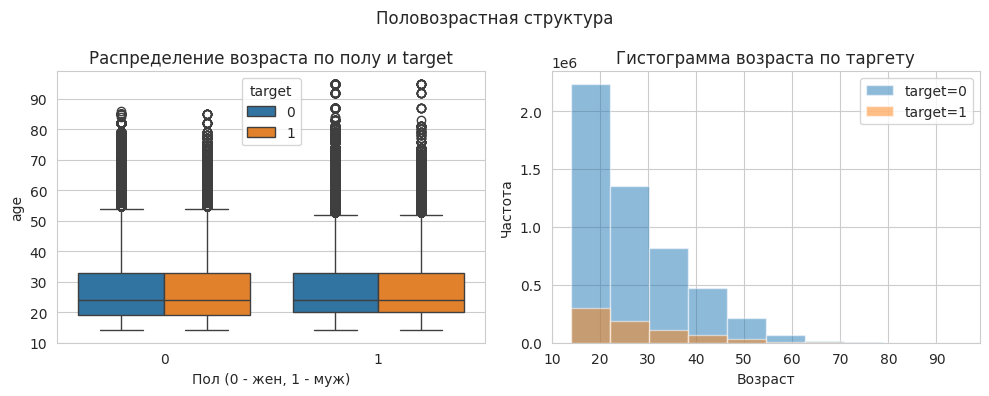

In [12]:
# половозрастная структура пользователей

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig1.suptitle('Половозрастная структура')

# boxplot возраст - пол, с разделением по таргету
sns.boxplot(data=df, x='gender', y='age', hue='target', ax=ax1)
ax1.set_title('Распределение возраста по полу и target')
ax1.set_xlabel('Пол (0 - жен, 1 - муж)')

# возраст, сгруппированный по таргету
for t in df['target'].unique():
    subset = df[df['target'] == t]
    ax2.hist(subset['age'], alpha=0.5, label=f'target={t}', bins=10)
ax2.set_title('Гистограмма возраста по таргету')
ax2.set_xlabel('Возраст')
ax2.set_ylabel('Частота')
ax2.legend()

plt.tight_layout()
plt.show()

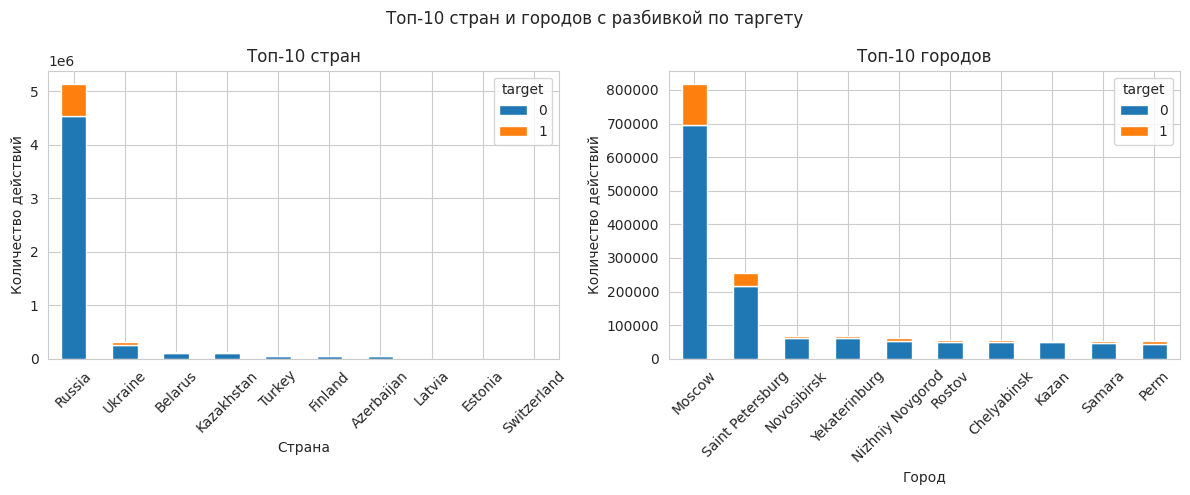

In [15]:
# страны и города: топ 10 с разбиением по таргету

top_countries = df['country'].value_counts().head(10).index.tolist() 
df_country_top = df[df['country'].isin(top_countries)]

top_cities = df['city'].value_counts().head(10).index.tolist()
df_city_top = df[df['city'].isin(top_cities)]

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Топ-10 стран и городов с разбивкой по таргету')

country_target = pd.crosstab(df_country_top['country'], df_country_top['target'])
country_target = country_target.reindex(top_countries)
country_target.plot(kind='bar', stacked=True, ax=ax3)
ax3.set_title('Топ-10 стран')
ax3.set_xlabel('Страна')
ax3.set_ylabel('Количество действий')
ax3.tick_params(axis='x', rotation=45)

city_target = pd.crosstab(df_city_top['city'], df_city_top['target'])
city_target = city_target.reindex(top_cities)
city_target.plot(kind='bar', stacked=True, ax=ax4)
ax4.set_title('Топ-10 городов')
ax4.set_xlabel('Город')
ax4.set_ylabel('Количество действий')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

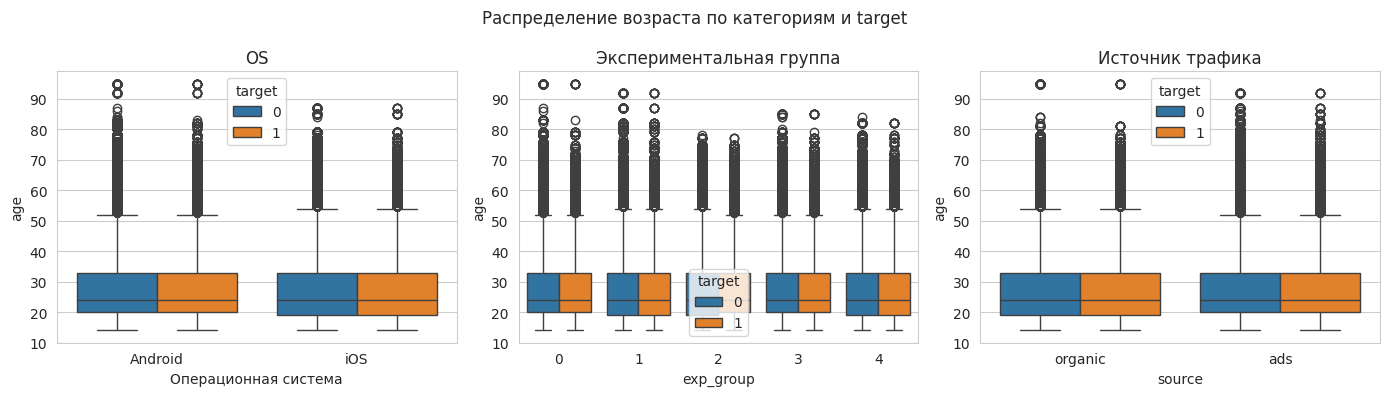

In [14]:
fig4, axes = plt.subplots(1, 3, figsize=(14, 4))
fig4.suptitle('Распределение возраста по категориям и target')

# boxplot: возраст по os
sns.boxplot(data=df, x='os', y='age', hue='target', ax=axes[0])
axes[0].set_title('OS')
axes[0].set_xlabel('Операционная система')

# boxplot: возраст по экспериментальной группе
sns.boxplot(data=df, x='exp_group', y='age', hue='target', ax=axes[1])
axes[1].set_title('Экспериментальная группа')
axes[1].set_xlabel('exp_group')

# boxplot: возраст по источнику трафика
sns.boxplot(data=df, x='source', y='age', hue='target', ax=axes[2])
axes[2].set_title('Источник трафика')
axes[2].set_xlabel('source')

plt.tight_layout()
plt.show()

## анализ взаимодействий

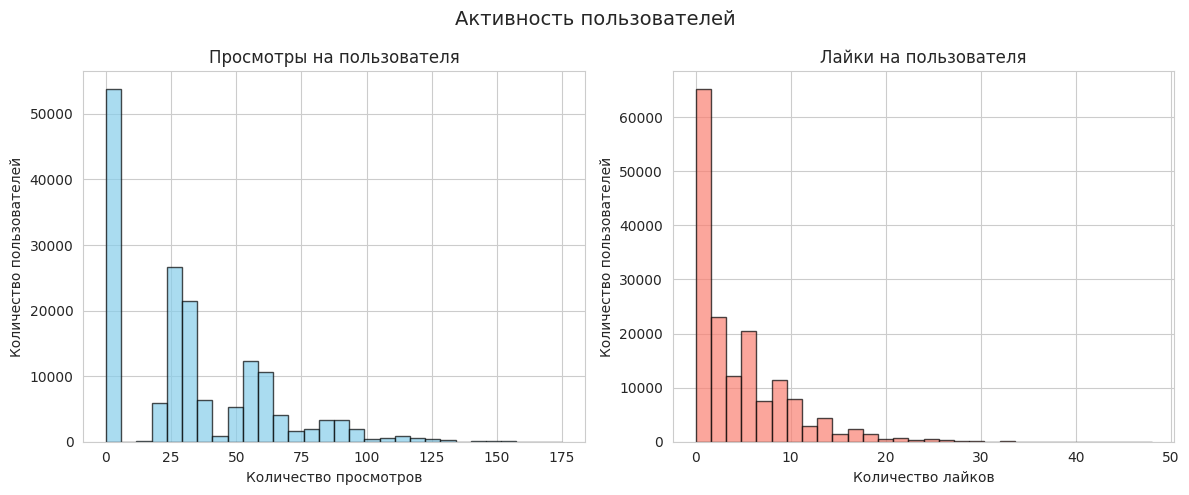

In [27]:
# расчет метрик на юзера
user_views = df[df['action'] == 'view'].groupby('user_id').size()
user_likes = df[df['action'] == 'like'].groupby('user_id').size()

user_metrics = pd.DataFrame({
    'views': user_views,
    'likes': user_likes
}).fillna(0)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('Активность пользователей', fontsize=14)

ax1.hist(user_metrics['views'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Просмотры на пользователя')
ax1.set_xlabel('Количество просмотров')
ax1.set_ylabel('Количество пользователей')

ax2.hist(user_metrics['likes'], bins=30, alpha=0.7, color='salmon', edgecolor='black')
ax2.set_title('Лайки на пользователя')
ax2.set_xlabel('Количество лайков')
ax2.set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

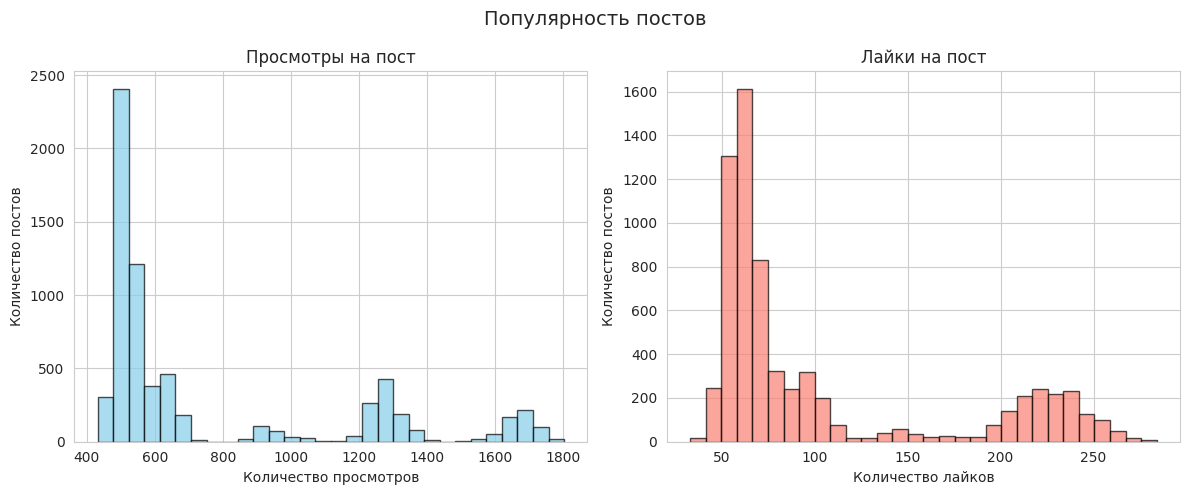

In [28]:
# расчет метрик на пост
post_views = df[df['action'] == 'view'].groupby('post_id').size()
post_likes = df[df['action'] == 'like'].groupby('post_id').size()

post_metrics = pd.DataFrame({
    'views': post_views,
    'likes': post_likes
}).fillna(0)

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Популярность постов', fontsize=14)

ax3.hist(post_metrics['views'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax3.set_title('Просмотры на пост')
ax3.set_xlabel('Количество просмотров')
ax3.set_ylabel('Количество постов')

ax4.hist(post_metrics['likes'], bins=30, alpha=0.7, color='salmon', edgecolor='black')
ax4.set_title('Лайки на пост')
ax4.set_xlabel('Количество лайков')
ax4.set_ylabel('Количество постов')

plt.tight_layout()
plt.show()

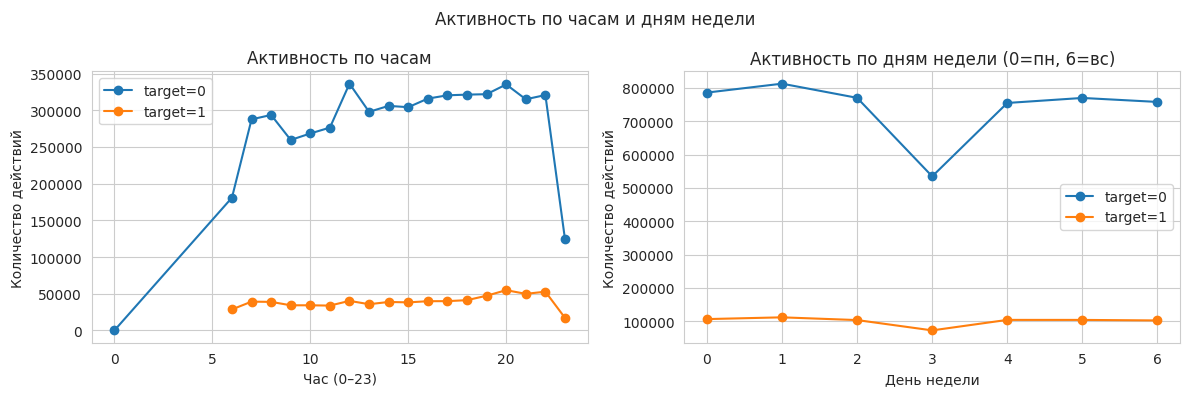

In [16]:
# активность по часам и дням недели с разделением по таргету

# группировка по часу и таргету
hour_target = df.groupby(['hour', 'target']).size().reset_index(name='count')
# группировка по дню недели и таргету
dow_target = df.groupby(['dayofweek', 'target']).size().reset_index(name='count')

fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle('Активность по часам и дням недели')

for t in df['target'].unique():
    data_h = hour_target[hour_target['target'] == t]
    ax5.plot(data_h['hour'], data_h['count'], marker='o', label=f'target={t}')
ax5.set_title('Активность по часам')
ax5.set_xlabel('Час (0–23)')
ax5.set_ylabel('Количество действий')
ax5.legend()

for t in df['target'].unique():
    data_d = dow_target[dow_target['target'] == t]
    ax6.plot(data_d['dayofweek'], data_d['count'], marker='o', label=f'target={t}')
ax6.set_title('Активность по дням недели (0=пн, 6=вс)')
ax6.set_xlabel('День недели')
ax6.set_ylabel('Количество действий')
ax6.legend()

plt.tight_layout()
plt.show()

## анализ текстов постов

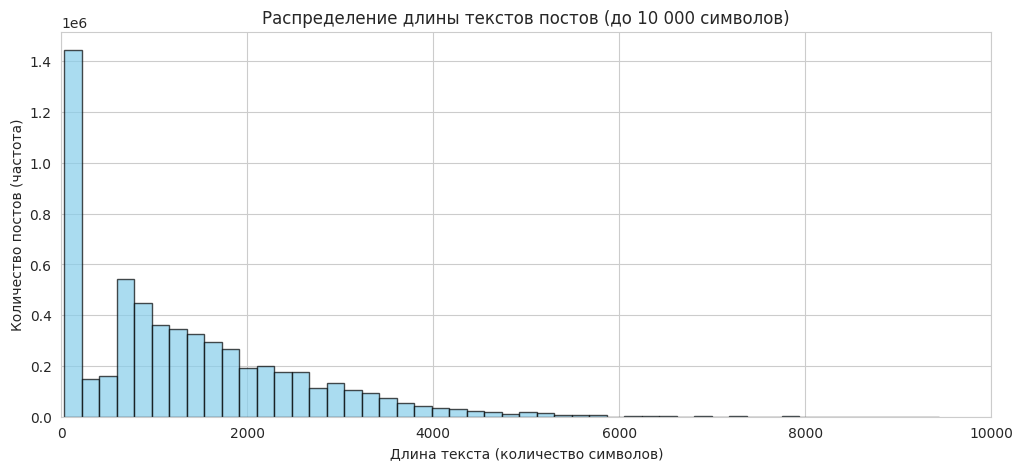

Постов длиннее 10000 символов: 8072 (0.14%)


In [39]:
df['text_len'] = df['text'].astype(str).apply(len)
len_subset = df['text_len'][df['text_len'] <= 10000] # ограничим для детализации

fig, ax = plt.subplots(figsize=(12,5))
plt.hist(len_subset, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlim(0, 10000)

plt.xlabel('Длина текста (количество символов)')
plt.ylabel('Количество постов (частота)')
plt.title('Распределение длины текстов постов (до 10 000 символов)')
plt.show()

long_posts = (df['text_len'] > 10000).sum()
print(f"Постов длиннее 10000 символов: {long_posts} ({long_posts/len(df)*100:.2f}%)")

Топ-10 самых частых слов: [('the', 277828), ('will', 17329), ('one', 13641), ('would', 13476), ('film', 12403), ('movie', 12102), ('out', 11062), ('people', 9050), ('can', 8454), ('time', 8379)]


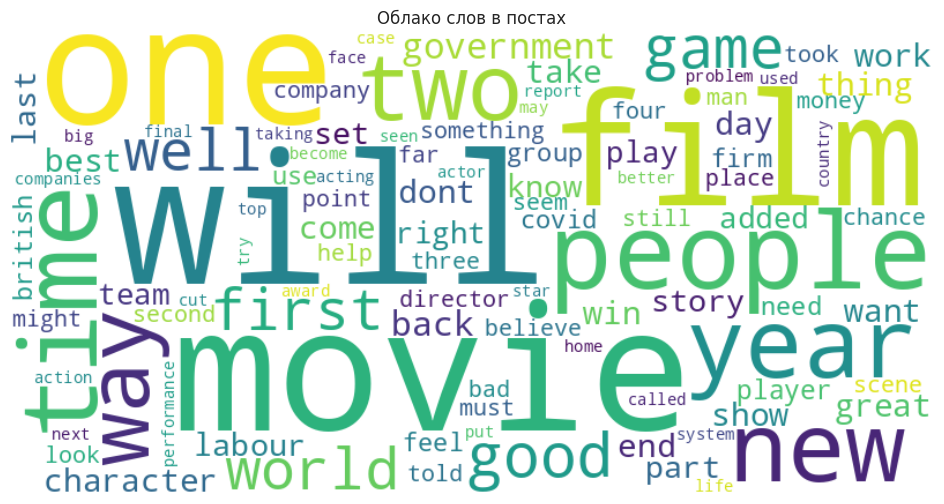

In [24]:
# для частотного анализа текста используем подвыборку - для экономии ресурсов
sample_size = min(20000, len(df))
text_sample = df['text'].sample(n=sample_size, random_state=42).astype(str)
text_sample = text_sample[text_sample.str.strip() != '']
    
if len(text_sample) > 0:
    def clean_text(txt):
        txt = txt.lower()
        txt = re.sub(r'[^a-z\s]', '', txt)  # английские буквы и пробелы
        words = txt.split()
        words = [w for w in words if w not in custom_stop_words and len(w) > 2]
        return ' '.join(words)
        
    all_words = ' '.join(text_sample.apply(clean_text)).split()
    word_freq = Counter(all_words)
    print("Топ-10 самых частых слов:", word_freq.most_common(10))
        
    from wordcloud import WordCloud
    text_for_cloud = ' '.join(all_words[:50000]) if len(all_words) > 50000 else ' '.join(all_words)
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100)
    wc.generate(text_for_cloud)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Облако слов в постах')
    plt.show()

In [37]:
report = f"""
=============================================================
                   ОТЧЕТ ПО РЕЗУЛЬТАТАМ EDA 
=============================================================
1. Общая информация:
   - Датасет содержит {df.shape[0]} записей, {df.shape[1]} колонок.
   - Временной диапазон: {df['timestamp'].min()} – {df['timestamp'].max()}
   - Дубликаты: {df.duplicated().sum()}

2. Пользователи и посты:
   - Уникальных пользователей: {len(user_views)}
   - Уникальных постов: {len(post_views)}
   - Среднее число просмотров на пользователя: {user_views.mean():.2f}
   - Медианное: {user_views.median():.1f}
   - Средняя популярность поста: {post_views.mean():.2f}, медиана: {post_views.median():.1f}

3. Временная динамика:
   - Пик активности приходится на час: {df['hour'].mode()[0]}
   - Наиболее активный день недели: {df['dayofweek'].mode()[0]} (0-пн)

4. Категориальные признаки:
   - Пол: {dict(df['gender'].value_counts())}
   - Возраст: средний {df['age'].mean():.1f}, разброс {df['age'].min()}–{df['age'].max()}
   - Страны: {df['country'].value_counts().to_dict()}
   - Экспериментальные группы: {dict(df['exp_group'].value_counts())}
   - ОС: {dict(df['os'].value_counts())}
   - Источник: {dict(df['source'].value_counts())}

5. Топики:
   - Всего топиков: {df['topic'].nunique()}
   - Самый популярный: {df['topic'].mode()[0]} 
     (доля {df['topic'].value_counts(normalize=True).max()*100:.1f}%)

6. Текстовые особенности:
   - Средняя длина текста: {df['text_len'].mean():.1f} символов
   - Топ-5 слов: {word_freq.most_common(5)}
   - Присутствуют как короткие новости, так и более длинные описания.
=============================================================
"""
print(report)


                   ОТЧЕТ ПО РЕЗУЛЬТАТАМ EDA 
1. Общая информация:
   - Датасет содержит 5890555 записей, 17 колонок.
   - Временной диапазон: 2021-10-27 16:42:51 – 2021-12-29 23:51:06
   - Дубликаты: 0

2. Пользователи и посты:
   - Уникальных пользователей: 158990
   - Уникальных постов: 6831
   - Среднее число просмотров на пользователя: 32.59
   - Медианное: 29.0
   - Средняя популярность поста: 758.54, медиана: 541.0

3. Временная динамика:
   - Пик активности приходится на час: 20
   - Наиболее активный день недели: 1 (0-пн)

4. Категориальные признаки:
   - Пол: {1: np.int64(3264436), 0: np.int64(2626119)}
   - Возраст: средний 27.2, разброс 14–95
   - Страны: {'Russia': 5130218, 'Ukraine': 312119, 'Belarus': 126681, 'Kazakhstan': 120710, 'Turkey': 62044, 'Finland': 59534, 'Azerbaijan': 54945, 'Latvia': 6396, 'Estonia': 6291, 'Switzerland': 5917, 'Cyprus': 5700}
   - Экспериментальные группы: {2: np.int64(1206000), 1: np.int64(1204965), 4: np.int64(1171876), 0: np.int64(1154034)